### Решение Хакатона от Finam трек Forecast

In [ ]:
import pandas as pd

In [2]:
train_candles = pd.read_csv("/kaggle/input/finam-hackathon/train_candles.csv")
public_test_candles = pd.read_csv("/kaggle/input/finam-hackathon/public_test_candles.csv")
private_test_candles = pd.read_csv("/kaggle/input/finam-hackathon/private_test_candles.csv")
train_news = pd.read_csv('/kaggle/input/finam-hackathon/train_news.csv')
test_news = pd.read_csv('/kaggle/input/finam-hackathon/test_news.csv')

In [3]:
train_candles.head()

,open,close,high,low,volume,begin,ticker,target_return_1d,target_direction_1d,target_return_20d,target_direction_20d
0,81.50,81.70,83.20,81.16,29755530,2020-06-19,AFLT,0.004896,1,0.071726,1
1,81.72,82.10,83.98,80.26,18502950,2020-06-22,AFLT,-0.010962,0,0.048477,1
2,82.04,81.20,82.48,80.40,16848930,2020-06-23,AFLT,-0.007635,0,0.048522,1
3,79.78,80.58,80.80,78.22,21559860,2020-06-25,AFLT,-0.014892,0,0.096550,1
4,80.50,79.38,81.44,78.76,14677280,2020-06-26,AFLT,0.044344,1,0.104056,1


In [4]:
public_test_candles.head()

,open,close,high,low,volume,begin,ticker
0,69.26,69.35,70.35,68.21,20618280,2025-04-16,AFLT
1,69.37,71.15,71.17,69.12,19219930,2025-04-17,AFLT
2,70.00,70.18,71.12,68.71,30588660,2025-04-18,AFLT
3,70.67,72.45,73.00,70.47,44269920,2025-04-21,AFLT
4,72.50,73.49,75.00,71.85,32850470,2025-04-22,AFLT


In [5]:
private_test_candles.head()

,open,close,high,low,volume,begin,ticker
0,70.11,70.07,70.37,69.80,1006410,2025-05-10,AFLT
1,71.00,71.04,72.03,70.63,5062370,2025-05-11,AFLT
2,71.30,72.10,72.97,71.11,16100660,2025-05-12,AFLT
3,72.16,71.29,72.38,71.16,10652260,2025-05-13,AFLT
4,71.27,68.56,71.54,68.50,17230550,2025-05-14,AFLT


In [7]:
train_news.head()

,Unnamed: 0,publish_date,title,publication
0,25389,2020-01-01 14:00:00,Ключевые российские нефтегазовые компании смот...,Тенденции в отрасли. Ключевые российские нефте...
1,25388,2020-01-02 15:00:00,ММК выгодно отличает высокая экспозиция на вну...,Тенденции в отрасли. Ключевые российские стале...
2,25387,2020-01-03 10:13:10,Контракты на поставку газа в Белоруссию и тран...,"Председатель правления ""Газпрома"" Алексей Милл..."
3,25386,2020-01-03 13:26:29,"ПАО ""ФосАгро"" -Внеочередное общее собрание",Дата и время ВОСА – 24.01.2020 23:59:59 Дата ...
4,25385,2020-01-03 13:44:03,"ПАО ""ММК"" - Внеочередное общее собрание- ИТОГИ",Дата и время собрания - 27.12.2019 00:00:00 Д...


In [10]:
test_news.head()

,Unnamed: 0,publish_date,title,publication
0,25389,2020-01-01 14:00:00,Ключевые российские нефтегазовые компании смот...,Тенденции в отрасли. Ключевые российские нефте...
1,25388,2020-01-02 15:00:00,ММК выгодно отличает высокая экспозиция на вну...,Тенденции в отрасли. Ключевые российские стале...
2,25387,2020-01-03 10:13:10,Контракты на поставку газа в Белоруссию и тран...,"Председатель правления ""Газпрома"" Алексей Милл..."
3,25386,2020-01-03 13:26:29,"ПАО ""ФосАгро"" -Внеочередное общее собрание",Дата и время ВОСА – 24.01.2020 23:59:59 Дата ...
4,25385,2020-01-03 13:44:03,"ПАО ""ММК"" - Внеочередное общее собрание- ИТОГИ",Дата и время собрания - 27.12.2019 00:00:00 Д...


In [4]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=eedf6ee2b8940cb6fd0aa5e6a5cecda8649011121173cd39bd2a41afa361dcfb
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [11]:
!pip install transliterate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.9 MB/s eta 0:00:00


In [5]:
# Импорт библиотек
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.preprocessing import RobustScaler
import warnings
import os
from tqdm import tqdm
import torch.nn.functional as F
import re
import time
import json
from openai import (
    OpenAI,
    APIStatusError,
    APIConnectionError,
    RateLimitError,
    AuthenticationError
)
warnings.filterwarnings('ignore')
SEED = 42 # Задаю seed
# Путь к файлам
CANDLES_PATH_1 = "/kaggle/input/finam-hackathon/candles.csv"
CANDLES_PATH_2 = "/kaggle/input/finam-hackathon/candles_2.csv"
NEWS_PATH_1 = "/kaggle/input/finam-hackathon/news.csv"
NEWS_PATH_2 = "/kaggle/input/finam-hackathon/news_2.csv"
# Последний день в train
TRAIN_CUTOFF = pd.Timestamp('2025-09-08')
INPUT_WINDOW = 60 #Длина временной последовательности, которую модель принимает на вход
PRED_HORIZON = 20 # Горизонт прогнозирования (дней)
OPENROUTE_API_KEY = "key" # Ключ для доступа к OpenRouter API ( выдавался организаторами)

# Установка seed
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\n 1. Загрузка и объединение данных...")
# Функция для загрузки и объединения файлов свечей и новостей.
def load_and_merge_data():
    candles_1 = pd.read_csv(CANDLES_PATH_1)
    candles_2 = pd.read_csv(CANDLES_PATH_2)
    candles_df = pd.concat([candles_1, candles_2], ignore_index=True)
    news_1 = pd.read_csv(NEWS_PATH_1)
    news_2 = pd.read_csv(NEWS_PATH_2)
    news_df = pd.concat([news_1, news_2], ignore_index=True)
    if 'begin' in candles_df.columns:
        candles_df["begin"] = pd.to_datetime(candles_df["begin"])
        candles_df = candles_df.sort_values(['ticker', 'begin']).reset_index(drop=True)
    if 'publish_date' in news_df.columns:
        news_df["publish_date"] = pd.to_datetime(news_df["publish_date"])

    return candles_df, news_df
CANDLES, NEWS = load_and_merge_data()
TRAIN_TICKERS = CANDLES[CANDLES['begin'] <= TRAIN_CUTOFF]['ticker'].unique()
# Словарь, содержащий ключевые слова для каждого тикера. Используется для первичной фильтрации новостей, чтобы определить, к какой компании новость относится.
TICKER_KEYWORDS = {
    "GAZP": ["Газпром", "Gazprom", "ГАЗП", "Gazprom Neft", "Нефть", "Трамп", "Путин"],
    "SBER": ["Сбербанк", "Sberbank", "СБЕР", "Сбер", "Банк", "Ключевая ставка", "Трамп", "Путин"],
    "SBERP": ["Сбербанк-п", "Sberbank-p", "СБЕР-п", "Банк", "Ключевая ставка", "Трамп", "Путин"],
    "LKOH": ["Лукойл", "Lukoil", "ЛУКОЙЛ", "Трамп", "Путин"],
    "GMKN": ["Норникель", "Nornickel", "ГМК", "Трамп", "Путин"],
    "YNDX": ["Яндекс", "Yandex", "YNDX", "Трамп", "Путин"],
    "VTBR": ["ВТБ", "VTB", "ВТБ Банк", "Банк", "Ключевая ставка", "Трамп", "Путин"],
    "ROSN": ["Роснефть", "Rosneft", "РОСНЕФТЬ", "Трамп", "Путин"],
    "NVTK": ["НОВАТЭК", "Novatek", "Трамп", "Путин"],
    "SIBN": ["Газпром нефть", "Gazprom Neft", "ГАЗПРОМ НЕФТЬ", "Трамп", "Путин"],
    "PHOR": ["ФосАгро", "PhosAgro", "ФОСАГРО", "Трамп", "Путин"],
    "PLZL": ["Полюс Золото", "Polyus", "ПОЛЮС", "Трамп", "Путин"],
    "MTSS": ["МТС", "MTS", "МТС Банк", "Трамп", "Путин"],
    "MGNT": ["Магнит", "Magnit", "МАГНИТ", "Трамп", "Путин"],
    "CHMF": ["Северсталь", "Severstal", "СЕВЕРСТАЛЬ", "Трамп", "Путин"],
    "NLMK": ["НЛМК", "NLMK", "Новолипецкий металлургический комбинат", "Трамп", "Путин"],
    "ALRS": ["АЛРОСА", "Alrosa", "Трамп", "Путин"],
    "RUAL": ["РУСАЛ", "Rusal", "Трамп", "Путин"],
    "AFKS": ["АФК Система", "AFK Sistema", "СИСТЕМА", "Трамп", "Путин"],
    "MOEX": ["Московская биржа", "MOEX", "БИРЖА", "Трамп", "Путин"],
    "HYDR": ["РусГидро", "RusHydro", "РУСГИДРО", "Трамп", "Путин"],
    "IRAO": ["Интер РАО", "Inter RAO", "ИНТЕР РАО", "Трамп", "Путин"],
    "AFLT": ["Аэрофлот", "Aeroflot", "АЭРОФЛОТ", "Трамп", "Путин"],
    "SNGS": ["Сургутнефтегаз", "Surgutneftegas", "СНГ", "Трамп", "Путин"],
    "SNGSP": ["Сургутнефтегаз-п", "Surgutneftegas-p", "СНГ-п", "Трамп", "Путин"],
    "TATN": ["Татнефть", "Tatneft", "ТАТНЕФТЬ", "Трамп", "Путин"],
    "TATNP": ["Татнефть-п", "Tatneft-p", "ТАТНЕФТЬ-п", "Трамп", "Путин"],
    "VTBRP": ["ВТБ-п", "VTB-p", "ВТБ Банк-п", "Трамп", "Путин"],
    "MGNP": ["Магнит-п", "Magnit-p", "МАГНИТ-п", "Трамп", "Путин"],
    "TRNFP": ["Транснефть", "Transneft", "ТРАНСНЕФТЬ", "Трамп", "Путин"],
    "TRNF": ["Транснефть", "Transneft", "ТРАНСНЕФТЬ", "Трамп", "Путин"],
    "URKA": ["Уралкалий", "Uralkali", "УРАЛКАЛИЙ", "Трамп", "Путин"],
    "URKAP": ["Уралкалий-п", "Uralkali-p", "УРАЛКАЛИЙ-п", "Трамп", "Путин"],
    "BANE": ["Башнефть", "Bashneft", "Трамп", "Путин"],
    "FESH": ["ДВМП", "Дальневосточное морское пароходство", "FESCO", "Трамп", "Путин"],
    "UWGN": ["ОВК", "Объединенная вагонная компания", "ОВК", "Трамп", "Путин"],
    "T": ["Тинькофф Банк", "Tinkoff", "ТИНЬКОФФ", "Т-Банк", "Т", "Банк", "Ключевая ставка", "IT", "Трамп", "Путин"],
    "VKCO": ["VK Company", "VK", "ВКОНТАКТЕ", "IT", "Трамп", "Путин"],
    "PIKK": ["ПИК-специализированный застройщик", "PIK", "ПИК", "Трамп", "Путин"],
    "SMLT": ["Самолет", "Samolet", "САМОЛЕТ", "Трамп", "Путин"],
    "POSI": ["Positive Technologies", "ПОЗИТИВ", "Трамп", "Путин"],
    "FIVE": ["X5 Retail Group", "X5", "Х5", "Трамп", "Путин"],
    "SVCB": ["Совкомбанк", "Sovcombank", "СОВКОМБАНК", "Трамп", "Путин"],
    "SVCBP": ["Совкомбанк-п", "Sovcombank-p", "СОВКОМБАНК-п", "Трамп", "Путин"],
    "CIAN": ["ЦИАН", "CIAN Group", "ЦИАН ГРУПП", "Трамп", "Путин"],
    "HHRU": ["HeadHunter", "Хедхантер", "HH", "IT", "Трамп", "Путин"],
    "DELI": ["Делимобиль", "Delimobil", "ДЕЛИМОБИЛЬ", "Трамп", "Путин"],
    "DIAS": ["Диасофт", "Diasoft", "DIASOFT", "Трамп", "Путин"],
    "EVI": ["Европлан", "Europlan", "ЕВРОПЛАН", "Трамп", "Путин"],
    "MTBC": ["МТС Банк", "MTS Bank", "МТС-БАНК", "Трамп", "Путин"],
    "OZON": ["Озон", "Ozon Holdings", "OZON", "IT", "Трамп", "Путин"],
    "DATA": ["Аренадата", "Arenadata", "DATA", "Трамп", "Путин"],
    "SPBE": ["СПБ Биржа", "SPB Exchange", "СПБ", "Трамп", "Путин"],
    "CBOM": ["МКБ", "Moscow Credit Bank", "МОСКОВСКИЙ КРЕДИТНЫЙ БАНК", "Трамп", "Путин"],
    "PRMB": ["Промсвязьбанк", "PSB", "ПСБ", "Трамп", "Путин"],
    "ABIO": ["Астра", "ГК Астра", "Astra Group", "ASTRA", "Трамп", "Путин"],
    "SOFL": ["Софтлайн", "Softline", "СОФТЛАЙН", "Трамп", "Путин"],
    "DELPO": ["Депозитарный расписки", "Депозитарные расписки", "ГДР", "Трамп", "Путин"],
    "RASP": ["Распадская", "Raspadskaya", "РАСПАДСКАЯ", "Трамп", "Путин"],
    "POLY": ["Полиметалл", "Polymetal", "ПОЛИМЕТАЛЛ", "Трамп", "Путин"],
    "RUALP": ["РУСАЛ-п", "Rusal-p"],
    "MAGN": ["ММК", "MMK", "Магнитогорский металлургический комбинат", "Трамп", "Путин"],
    "MSNG": ["Мечел", "Mechel", "МЕЧЕЛ", "Трамп", "Путин"],
    "TRMK": ["ТМК", "Трубная металлургическая компания", "TMK", "Трамп", "Путин"],
    "KMAZ": ["КАМАЗ", "KAMAZ", "КАМАЗ", "Трамп", "Путин"],
    "VSMO": ["ВСМПО-Ависма", "VSMPO-AVISMA", "Трамп", "Путин"],
    "AKRN": ["Акрон", "Acron", "Трамп", "Путин"],
    "KZOS": ["Казаньоргсинтез", "Kazanorgsintez", "КОС", "Трамп", "Путин"],
    "GCHE": ["Группа Черкизово", "Cherkizovo Group", "ЧЕРКИЗОВО", "Трамп", "Путин"],
    "RZSP": ["Русагро", "Rusagro", "РУСАГРО", "Трамп", "Путин"],
    "RZSPP": ["Русагро-п", "Rusagro-p", "РУСАГРО-п", "Трамп", "Путин"],
    "OKEY": ["О'КЕЙ", "O'KEY", "ОКЕЙ", "Трамп", "Путин"],
    "APTK": ["Аптечная сеть 36,6", "APTEKA 36,6", "АПТЕКА", "Трамп", "Путин"],
    "DIXY": ["Дикси Групп", "DIXY Group", "ДИКСИ", "Трамп", "Путин"],
    "ABRD": ["Абрау-Дюрсо", "Abrau-Durso", "АБРАУ", "Трамп", "Путин"],
    "MRKC": ["Россети Центр", "MRSK Center", "МРСК ЦЕНТРА", "Трамп", "Путин"],
    "MRKU": ["Россети Урал", "MRSK Urala", "МРСК УРАЛА", "Трамп", "Путин"],
    "MRKP": ["Россети Центр и Приволжье", "MRSK Center & Privolzhye", "МРСК ЦИП", "Трамп", "Путин"],
    "MRKV": ["Россети Волга", "MRSK Volga", "МРСК ВОЛГА", "Трамп", "Путин"],
    "MSRS": ["Россети Московский регион", "МОЭСК", "MSRS", "Трамп", "Путин"],
    "MRKK": ["Россети Северный Кавказ", "MRK-SK", "РОССЕТИ СК", "Трамп", "Путин"],
    "MRKY": ["Россети Юг", "MRK-Yug", "РОССЕТИ ЮГ", "Трамп", "Путин"],
    "MRKZ": ["Россети Северо-Запад", "MRSK SZ", "МРСК СЗ", "Трамп", "Путин"],
    "FEES": ["ФСК ЕЭС", "FSK EES", "ФСК", "Трамп", "Путин"],
    "OGKB": ["ОГК-2", "OGK-2", "Трамп", "Путин"],
    "TGKA": ["ТГК-1", "TGK-1", "Трамп", "Путин"],
    "TGLD": ["ТГК-1", "ТГК-1", "TGC-1", "Трамп", "Путин"],
    "TGKB": ["ТГК-2", "TGK-2", "Трамп", "Путин"],
    "TGKN": ["ТГК-14", "TGK-14", "Трамп", "Путин"],
    "BELU": ["Белуга Групп", "BELUGA Group", "БЕЛУГА", "Трамп", "Путин"],
    "ETLN": ["Эталон", "Etalon Group", "ЭТАЛОН", "Трамп", "Путин"],
    "SGZH": ["Сегежа Групп", "Segezha Group", "СЕГЕЖА", "Трамп", "Путин"],
    "LSRG": ["ЛСР", "LSR Group", "Группа ЛСР", "Трамп", "Путин"],
    "GEMC": ["Мать и дитя", "MD Medical Group", "МАТЬ И ДИТЯ", "Трамп", "Путин"],
    "AQUA": ["Аквакультура", "РусАквакультура", "AQUA", "Трамп", "Путин"],
    "RTKM": ["Ростелеком", "Rostelecom", "РОСТЕЛЕКОМ", "Трамп", "Путин"],
    "RTKMP": ["Ростелеком-п", "Rostelecom pref", "РОСТЕЛЕКОМ-п", "Трамп", "Путин"],
    "RENI": ["Ренессанс Страхование", "РЕНЕССАНС СТРАХОВАНИЕ", "Трамп", "Путин"],
    "ZAYM": ["Займер", "Zaymer", "ЗАЙМЕР", "Трамп", "Путин"],
    "ZAYMP": ["Займер-п", "Zaymer-p", "ЗАЙМЕР-п", "Трамп", "Путин"],
    "PHST": ["Фармсинтез", "Pharmasynthez", "ФАРМСИНТЕЗ", "Трамп", "Путин"],
    "RSG": ["РусГидро", "RusHydro", "РУСГИДРО", "Трамп", "Путин"],
    "LSNGP": ["Ленэнерго-п", "Lenenergo-p", "ЛЕНЭНЭРГО-п", "Трамп", "Путин"],
    "GAZT": ["ГАЗ-Тек", "GAZ-Tek", "ГАЗТЕК", "Трамп", "Путин"],
    "IRKT": ["Иркут", "Irkut", "Трамп", "Путин"],
    "UNAC": ["ОАК", "Объединённая авиастроительная корпорация", "Трамп", "Путин"],
    "NKNC": ["Нижнекамскнефтехим", "Nizhnekamskneftekhim", "Трамп", "Путин"],
    "CHKZ": ["Челябинский кузнечно-прессовый завод", "ЧКПЗ", "Трамп", "Путин"],
    "CHMK": ["Челябинский металлургический комбинат", "ЧМК", "Трамп", "Путин"],
    "ALNU": ["Алмазная промышленность", "ALNU", "Трамп", "Путин"],
    "OKB": ["ОК 'Русь'", "OK", "OKB", "Трамп", "Путин"],
    "ISKJ": ["ГК Самолет", "Samolet Group", "САМОЛЕТ-ИСК", "Трамп", "Путин"],
    "AKB": ["АК БАРС", "Ak Bars Bank", "АКБАРС", "Трамп", "Путин"]
}
def call_llm_for_features(news_text: str, ticker: str, api_key: str) -> tuple[int, int]:
    # Инициализация клиента OpenAI
    client = OpenAI(
        api_key=api_key,
        base_url="https://openrouter.ai/api/v1"
    )
    # Системный промпт
    system_prompt = (
        "You are an expert financial analyst. Analyze the following news article for "
        f"stock ticker {ticker}. Output the result strictly in JSON format: "
        '{"sentiment": N, "impact": M}, where N is the sentiment (integer from -3 to 3, '
        'and M is the market impact (integer from 0 to 5). '
        "Do not include any other text or explanation."
    )
    # Устанавливает максимальное количество повторных попыток при сбоях API.
    max_retries = 3
    for attempt in range(max_retries):
        try:
            # логирование запроса
            print("\n" + "="*50)
            print(f"[{ticker}]  Подготовка запроса к LLM:")
            print(news_text[:500] + ("..." if len(news_text) > 500 else ""))
            print("="*50)

            completion = client.chat.completions.create( # Отправка запроса к LLM.
                extra_headers={"OpenRouter-App-Title": "Financial Feature Extractor"},
                model="openai/gpt-3.5-turbo", # Использовал умную модель
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": news_text}
                ],
                response_format={"type": "json_object"},
                temperature=0.0 # Установка температуры в 0.0 для получения детерминированных ответов.
            )

            response_text = completion.choices[0].message.content
            data = json.loads(response_text)
            # логирование ответа
            print(f"[{ticker}]  Ответ LLM:")
            print(json.dumps(data, indent=2, ensure_ascii=False))
            return data.get("sentiment", 0), data.get("impact", 0) # возвращаем настроение(sentiment) и влияние(impact) новости

        except (APIStatusError, APIConnectionError, RateLimitError, json.JSONDecodeError) as e:
            print(f"[{ticker}]  Ошибка при вызове API: {type(e).__name__} - {e}")
            if attempt < max_retries - 1:
                print(f"[{ticker}] Повторная попытка ({attempt+2}/{max_retries})...")
                time.sleep(2 ** attempt)
                continue
            return 0, 0
        except Exception as e:
            print(f"[{ticker}]  Неожиданная ошибка: {type(e).__name__} - {e}")
            return 0, 0
    return 0, 0

class NewsFeatureExtractor:
    def __init__(self, news_df, candles_df, ticker_keywords, train_cutoff, api_key, max_api_calls=5000):
        self.news_df = news_df
        self.candles_df = candles_df
        self.ticker_keywords = ticker_keywords
        self.train_cutoff = train_cutoff
        self.api_key = api_key
        self.max_api_calls = max_api_calls
        self.llm_results = {}
        self.api_calls = 0
        self.log_records = []

    def extract_features(self, train_tickers):
        print(f" Запуск анализа новостей для тикеров из TRAIN...")
        # Анализируем новости только для тикеров, входящих в тренировочную выборку.
        for ticker, keywords in self.ticker_keywords.items():
            if ticker not in train_tickers:
                continue

            if self.api_calls >= self.max_api_calls:
                print(" Достигнут лимит API вызовов")
                break
            # Создание шаблона для регулярного выражения.
            keyword_pattern = '|'.join([re.escape(k) for k in keywords])
            news_filtered = self.news_df[
                self.news_df['title'].str.contains(keyword_pattern, case=False, na=False)
            ].copy()

            if news_filtered.empty:
                continue
            # Сортировка для выбора 30 самых свежих новостей для этого тикера.
            news_filtered.sort_values('publish_date', inplace=True, ascending=False)
            recent_news = news_filtered.head(30)

            results = []
            for _, row in recent_news.iterrows():
                if self.api_calls >= self.max_api_calls:
                    break

                news_text = f"Title: {row['title']}\nPublication: {row['publication']}"
                response = call_llm_for_features(news_text, ticker, self.api_key)
                self.api_calls += 1
                # Логирование каждого запроса и ответа.
                self.log_records.append({
                    'ticker': ticker,
                    'date': row['publish_date'],
                    'title': row['title'],
                    'publication': row['publication'],
                    'llm_response': response
                })

                if response:
                    results.append(response)

            if results:
                self.llm_results[ticker] = results
        # Сохранение всех результатов LLM в файл
        if self.log_records:
            import pandas as pd
            pd.DataFrame(self.log_records).to_csv('llm_news_logs.csv', index=False, encoding='utf-8-sig')
            print(f" LLM анализ новостей сохранён ({len(self.log_records)} записей)")

        return self.llm_results



# Cтандартный способ кодирования позиции в трансформерах.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]
# Реализация Темпоральной Сверточной Сети (TCN) для извлечения временных зависимостей
class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.3):
        super().__init__()
        self.layers = nn.ModuleList()
        num_levels = len(num_channels)

        for i in range(num_levels):
            dilation_size = 2 ** i # Дилатация увеличивается экспоненциально
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            conv = nn.Conv1d(
                in_channels, out_channels, kernel_size,
                padding=(dilation_size * (kernel_size - 1)) // 2,
                dilation=dilation_size
            )
            self.layers.append(nn.Sequential(
                conv,
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.Dropout(dropout)
            ))

        self.output_channels = num_channels[-1]

    def forward(self, x):
        x = x.transpose(1, 2) # Перестановка осей (Batch, Seq_len, Features) -> (Batch, Features, Seq_len) — необходима для torch.nn.Conv1d.
        for layer in self.layers:
            x = layer(x)
        return x.transpose(1, 2)  # Обратная перестановка осей.
# Гибридная модель, сочетающая TCN и Transformer Encoder
class ImprovedForecastModel(nn.Module):
    def __init__(self, input_dim=23, hidden_dim=128, num_layers=4,
                 num_heads=8, dropout=0.2, pred_horizon=20):
        super().__init__()

        self.pred_horizon = pred_horizon
        self.hidden_dim = hidden_dim

        self.feature_proj = nn.Linear(input_dim, hidden_dim) # Линейный слой для проецирования входных признаков в размерность модели
        self.pos_encoder = PositionalEncoding(hidden_dim)
        self.tcn = TemporalConvNet( # Блок TCN для извлечения локальных и долгосрочных зависимостей.
            hidden_dim,
            [hidden_dim, hidden_dim, hidden_dim],
            kernel_size=7,
            dropout=dropout
        )
        encoder_layer = nn.TransformerEncoderLayer( # Определение одного слоя Transformer Encoder
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation=F.gelu,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # Полный Transformer Encoder
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.final_repr_proj = nn.Linear(3 * hidden_dim, hidden_dim) # Проекция объединенных пулинговых представлений

        self.return_heads = nn.ModuleList([ # Список отдельных голов предсказания для *каждого* дня в горизонте прогноза (20 голов)
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, 1)
            ) for _ in range(pred_horizon)
        ])

        self.prob_heads = nn.ModuleList([ # Список отдельных голов предсказания направления (вероятности роста) для каждого дня.
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, 1),
                nn.Sigmoid()
            ) for _ in range(pred_horizon)
        ])

        self.global_return_head = nn.Sequential( # Единая голова, предсказывающая все 20 доходностей сразу. Используется для регуляризации и улучшения общей когерентности
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, pred_horizon)
        )

    def forward(self, x):
        x = self.feature_proj(x) # Проецирование входных признаков.
        x = self.pos_encoder(x) # Добавление позиционного кодирования.

        tcn_out = self.tcn(x) # Выход TCN.
        trans_out = self.transformer(x) # Выход Transformer.
        combined = tcn_out + trans_out + x # Суммирование выходов TCN, Transformer и исходного эмбеддинга
        attn_output, _ = self.attention(combined, combined, combined) # Применение дополнительного внимания к объединенному представлению.
        last_state = attn_output[:, -1, :] #  берем последнее состояние последовательности.
        avg_state = attn_output.mean(dim=1) # берем среднее состояние по всей последовательности.
        max_state = attn_output.max(dim=1)[0] # берем максимальное состояние по всей последовательности.
        pooled = torch.cat([last_state, avg_state, max_state], dim=-1) # Конкатенация трех пулинговых представлений.
        final_repr = self.final_repr_proj(pooled) # Финальное скрытое представление, используемое для предсказаний.

        daily_returns = []
        daily_probs = []

        for i in range(self.pred_horizon):
            daily_returns.append(self.return_heads[i](final_repr)) # Предсказание доходности по каждой отдельной голове.
            daily_probs.append(self.prob_heads[i](final_repr)) # Предсказание вероятности по каждой отдельной голове.

        daily_returns = torch.cat(daily_returns, dim=1) # Объединение предсказаний доходности в один тензор размера (Batch, PRED_HORIZON).
        daily_probs = torch.cat(daily_probs, dim=1) # Объединение предсказаний вероятности в один тензор.
        global_returns = self.global_return_head(final_repr) # Предсказание с помощью глобальной головы.
        final_returns = 0.7 * daily_returns + 0.3 * global_returns # Финальный прогноз доходности - взвешенная сумма прогнозов от отдельных голов и глобальной головы.

        return final_returns, daily_probs
# Класс для подготовки данных временных рядов и признаков.
class ImprovedTimeSeriesDataset(Dataset):
    def __init__(self, df, llm_features_df, seq_len=60, pred_horizon=20,
                 feature_scaler=None, is_train=True, llm_weight=1):

        self.seq_len = seq_len
        self.pred_horizon = pred_horizon
        self.is_train = is_train
        self.llm_weight = llm_weight

        df_agg = df.groupby("begin").agg({ # Агрегация данных свечей до дневного уровня (например, берем 'close' от последней свечи, 'high' - максимальный)
            "open": "first",
            "high": "max",
            "low": "min",
            "close": "last",
            "volume": "sum"
        }).reset_index()
        df_agg = df_agg.set_index("begin").asfreq("D").ffill().reset_index() # Заполнение пропущенных дней (например, выходных) предыдущими значениями (forward fill)

        # Сдвигаем новости на +1 день
        llm_features_df_shifted = llm_features_df.copy()
        llm_features_df_shifted['begin'] = llm_features_df_shifted['begin'] + pd.Timedelta(days=1)

        llm_features_df_shifted = llm_features_df_shifted.drop_duplicates(subset=['ticker', 'begin'])
        df_agg = pd.merge(df_agg, llm_features_df_shifted.drop(columns='ticker', errors='ignore'),
                          on='begin', how='left') # Объединение данных свечей с признаками LLM по дате

        llm_cols = [col for col in llm_features_df_shifted.columns if col not in ['ticker', 'begin']]
        for col in llm_cols:
            df_agg[col] = df_agg[col].fillna(0.0) # Заполнение пропусков в LLM-признаках (для дней без новостей) нулями

        self.features = self._create_features(df_agg, llm_cols)
        if is_train:
            self.targets = self._create_targets(df_agg)
        else:
            self.targets = None

        self.close_prices = df_agg['close'].values

        # Скейлер
        if feature_scaler is None:
            self.feature_scaler = RobustScaler()
            if self.features.size > 0:
                self.features = self.feature_scaler.fit_transform(self.features) # обучаем RobustScaler на данных и применяем его
        else:
            self.feature_scaler = feature_scaler
            if self.features.size > 0:
                self.features = self.feature_scaler.transform(self.features) # В режиме валидации/тестирования: применяем уже обученный скейлер.

        self.valid_indices = self._get_valid_indices()

    def _create_features(self, df, llm_cols):
        features = []
        # добавление логарифмов цен и объема
        features.append(np.log(df['open']).values)
        features.append(np.log(df['high']).values)
        features.append(np.log(df['low']).values)
        features.append(np.log(df['close']).values)
        features.append(np.log(df['volume'] + 1).values)

        # Лог-доходность
        log_returns = np.log(df['close'] / df['close'].shift(1)).fillna(0)
        features.append(log_returns.values)
        features.append(log_returns.rolling(20).std().fillna(0).values)

        # Расчет RSI - Relative Strength Index
        delta = df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        features.append(rsi.fillna(50).values / 100.0)

        # Расчет скользящих средних MA5 / MA20
        ma5 = df['close'].rolling(5).mean()
        ma20 = df['close'].rolling(20).mean()
        features.append((ma5 / ma20 - 1).fillna(0).values)

        features.append((df['volume'] / df['volume'].shift(1) - 1).fillna(0).values)
        features.append(((df['high'] - df['low']) / df['close']).values)
        # MACD

        ema12 = df['close'].ewm(span=12, adjust=False).mean()
        ema26 = df['close'].ewm(span=26, adjust=False).mean()
        macd = ema12 - ema26
        features.append((macd / df['close']).fillna(0).values * 10)

        # ATR
        high_low = df['high'] - df['low']
        high_prevclose = np.abs(df['high'] - df['close'].shift(1))
        low_prevclose = np.abs(df['low'] - df['close'].shift(1))
        tr = pd.DataFrame({'hl': high_low, 'hpc': high_prevclose, 'lpc': low_prevclose}).max(axis=1)
        atr = tr.rolling(14).mean()
        features.append((atr / df['close']).fillna(0).values * 10)

        # Momentum
        momentum = df['close'].diff(10) / df['close'].shift(10)
        features.append(momentum.fillna(0).values)

        # Разные MA
        features.append(df['close'].rolling(30).std().fillna(0).values / df['close'].mean())

        vol_ma10 = df['volume'].rolling(10).mean()
        features.append((df['volume'] / vol_ma10 - 1).fillna(0).values)

        high_10 = df['high'].rolling(10).max()
        low_10 = df['low'].rolling(10).min()
        features.append(((df['close'] - low_10) / (high_10 - low_10 + 1e-8)).fillna(0.5).values)

        typical_price = (df['high'] + df['low'] + df['close']) / 3
        features.append((typical_price / typical_price.shift(1) - 1).fillna(0).values)

        ma50 = df['close'].rolling(50).mean()
        features.append((df['close'] / ma50 - 1).fillna(0).values)
        #  Доходность за последний год (250 торговых дней)
        annual_return = (df['close'] / df['close'].shift(250) - 1).fillna(0)
        features.append(annual_return.values )

        # Волатильность за 100 дней (стандартное отклонение лог-доходности)
        volatility_100d = log_returns.rolling(100).std().fillna(0)
        features.append(volatility_100d.values )

        # Положение относительно 200-дневной скользящей средней (MA200)
        ma200 = df['close'].rolling(200).mean()
        ma200_rel_pos = (df['close'] / ma200 - 1).fillna(0)
        features.append(ma200_rel_pos.values )
        for col in llm_cols:
            features.append(df[col].values * self.llm_weight)

        return np.column_stack(features)


    def _create_targets(self, df):
        returns = []
        directions = []

        for h in range(1, self.pred_horizon + 1):
            if len(df['close']) <= h:
                ret = np.full(len(df), np.nan)
            else:
                ret = (df['close'].shift(-h) / df['close'] - 1).values # Расчет h-дневной доходности: (цена через h дней / текущая цена) - 1.

            returns.append(ret)
            directions.append((ret > 0).astype(float)) # Создание целевой переменной для классификации (1.0, если доходность > 0, 0.0 иначе)

        return {
            'returns': np.column_stack(returns),
            'directions': np.column_stack(directions)
        }
    # Метод для определения индексов, из которых можно корректно извлечь последовательность (X) и целевые значения (Y).
    def _get_valid_indices(self):
        valid = []

        if self.features.size == 0:
            return []

        end_idx = len(self.features) - self.pred_horizon if self.is_train else len(self.features) # Конечный индекс для формирования батчей.

        for i in range(self.seq_len, end_idx):
            if not np.isnan(self.features[i-self.seq_len:i]).any():
                if self.is_train and self.targets:
                    if not np.isnan(self.targets['returns'][i]).any():
                        valid.append(i)
                else:
                    valid.append(i)
        return valid

    def __len__(self):
        return len(self.valid_indices)
    # Метод для извлечения одного элемента данных по индексу.
    def __getitem__(self, idx):
        i = self.valid_indices[idx]
        X = torch.FloatTensor(self.features[i-self.seq_len:i])

        if self.is_train and self.targets:
            y_returns = torch.FloatTensor(self.targets['returns'][i])
            y_directions = torch.FloatTensor(self.targets['directions'][i])
            return X, y_returns, y_directions
        else:
            return X, torch.zeros(self.pred_horizon), torch.zeros(self.pred_horizon)


class CombinedLoss(nn.Module): # Комбинированная функция потерь для обучения модели одновременно регрессии и классификации.
    def __init__(self, alpha=0.5, beta=0.3, gamma=0.2):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.mse = nn.MSELoss()
        self.bce = nn.BCELoss()

    def forward(self, pred_returns, pred_probs, true_returns, true_directions):
        loss_mse = self.mse(pred_returns, true_returns) # Среднеквадратичная ошибка для регрессии доходности.
        loss_bce = self.bce(pred_probs, true_directions) # Бинарная кросс-энтропия для классификации направления

        pred_directions = (pred_returns > 0).float()
        loss_dir = 1.0 - (pred_directions == true_directions).float().mean() # Потери на основе ошибки направления (1.0 - accuracy направления).

        return self.alpha * loss_mse + self.beta * loss_bce + self.gamma * loss_dir # Взвешенная сумма трех компонент потерь.

def train_model(model, train_loader, val_loader, epochs=15, lr=1e-4, patience=5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( # Планировщик скорости обучения
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
    criterion = CombinedLoss()
    mse_criterion = nn.MSELoss()
    bce_criterion = nn.BCELoss()
    best_val_loss = float('inf')
    patience_counter = 0 # Счетчик для ранней остановки.

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} (Train)")
        for X, y_returns, y_directions in pbar:
            X = X.to(device)
            y_returns = y_returns.to(device)
            y_directions = y_directions.to(device)

            optimizer.zero_grad()
            pred_returns, pred_probs = model(X)
            loss = criterion(pred_returns, pred_probs, y_returns, y_directions)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Обрезка градиентов (gradient clipping) для предотвращения взрыва градиентов.
            optimizer.step()

            train_loss += loss.item()
            train_batches += 1
            pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

        avg_train_loss = train_loss / train_batches

        model.eval()
        val_loss = 0.0
        val_mse_sum = 0.0
        val_bce_sum = 0.0
        val_dir_acc_sum = 0.0
        val_batches = 0

        with torch.no_grad():
            for X, y_returns, y_directions in val_loader:
                X = X.to(device)
                y_returns = y_returns.to(device)
                y_directions = y_directions.to(device)

                pred_returns, pred_probs = model(X)

                loss = criterion(pred_returns, pred_probs, y_returns, y_directions)
                val_loss += loss.item()

                val_mse_sum += mse_criterion(pred_returns, y_returns).item()
                val_bce_sum += bce_criterion(pred_probs, y_directions).item()
                pred_directions = (pred_returns > 0).float()
                val_dir_acc_sum += (pred_directions == y_directions).float().mean().item()

                val_batches += 1

        avg_val_loss = val_loss / val_batches
        avg_val_mse = val_mse_sum / val_batches
        avg_val_bce = val_bce_sum / val_batches
        avg_val_acc = val_dir_acc_sum / val_batches

        scheduler.step(avg_val_loss) # Шаг планировщика LR на основе валидационной ошибки.

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val MSE: {avg_val_mse:.5f} | Val BCE: {avg_val_bce:.4f} | Val Acc: {avg_val_acc:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if os.path.exists('best_model.pt'):
        model.load_state_dict(torch.load('best_model.pt'))
    return model

extractor = NewsFeatureExtractor(
    NEWS, CANDLES, TICKER_KEYWORDS,
    TRAIN_CUTOFF, OPENROUTE_API_KEY
)
LLM_FEATURES = extractor.extract_features(train_tickers=TRAIN_TICKERS)
# Преобразование словаря результатов LLM в DataFrame.

llm_rows = []
for ticker, results_list in LLM_FEATURES.items():
    for i, (sentiment, impact) in enumerate(results_list):
        date = extractor.log_records[i]['date'] if i < len(extractor.log_records) else None
        llm_rows.append({
            'ticker': ticker,
            'begin': date,
            'sentiment': sentiment,
            'impact': impact
        })

LLM_FEATURES_DF = pd.DataFrame(llm_rows)
LLM_FEATURES_DF['begin'] = pd.to_datetime(LLM_FEATURES_DF['begin'])

ticker_data = {}
for ticker in TRAIN_TICKERS: # Подготовка данных для каждого тикера, разделение на train и val.
    df_ticker = CANDLES[CANDLES['ticker'] == ticker].copy()
    llm_ticker = LLM_FEATURES_DF[LLM_FEATURES_DF['ticker'] == ticker].copy()

    df_train = df_ticker[df_ticker['begin'] <= TRAIN_CUTOFF].copy() # train до даты отсечения.
    val_start = TRAIN_CUTOFF - pd.Timedelta(days=INPUT_WINDOW)
    df_val = df_ticker[df_ticker['begin'] >= val_start].copy() # val.

    ticker_data[ticker] = {
        'train': df_train,
        'val': df_val,
        'llm': llm_ticker
    }

val_window = 200 # Размер окна, выделяемого из обучающей выборки для валидации.

train_datasets = []
val_datasets = []
feature_scaler = None

for i, ticker in enumerate(TRAIN_TICKERS):
    data = ticker_data[ticker]

    if len(data['train']) < INPUT_WINDOW + PRED_HORIZON:
        continue

    df_train = data['train'].iloc[:-val_window]  # Вся история до val_window.
    train_ds = ImprovedTimeSeriesDataset(
        df_train,
        data['llm'],
        seq_len=INPUT_WINDOW,
        pred_horizon=PRED_HORIZON,
        is_train=True
    )
    if i == 0:
        feature_scaler = train_ds.feature_scaler # Сохраняем скейлер, обученный на первом тикере.
    if len(train_ds) > 0:
        train_datasets.append(train_ds)

    df_val = data['train'].iloc[-val_window:]
    val_ds = ImprovedTimeSeriesDataset(
        df_val,
        data['llm'],
        seq_len=INPUT_WINDOW,
        pred_horizon=PRED_HORIZON,
        feature_scaler=feature_scaler,
        is_train=True
    )
    if len(val_ds) > 0:
        val_datasets.append(val_ds)

train_dataset = ConcatDataset(train_datasets)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = ConcatDataset(val_datasets) if val_datasets else None
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False) if val_dataset else None

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset) if val_dataset else 0}")


print("\n Обучение модели")

model = ImprovedForecastModel(
    pred_horizon=PRED_HORIZON
).to(device)

print(f"Model on: {device}")

trained_model = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=5e-4,
    patience=5
)


print("\n Генерация прогнозов")

def generate_forecast( # Функция для генерации прогноза для одного тикера на основе обученной модели.
    model, df_ticker, llm_ticker, feature_scaler, date_t,
    clip_pct=0.03, smooth_alpha=0.3, llm_weight=0.2
):
    model.eval()

    df_cut = df_ticker[df_ticker['begin'] <= date_t].copy() # Берем данные до даты отсечения.
    if len(df_cut) < INPUT_WINDOW:
        return {'R': np.zeros(PRED_HORIZON), 'P': np.zeros(PRED_HORIZON), 'prices': np.zeros(PRED_HORIZON)}

    ds = ImprovedTimeSeriesDataset(
        df_cut,
        llm_ticker,
        seq_len=INPUT_WINDOW,
        pred_horizon=PRED_HORIZON,
        feature_scaler=feature_scaler,
        is_train=False
    )

    if len(ds) == 0:
        return {'R': np.zeros(PRED_HORIZON), 'P': np.zeros(PRED_HORIZON), 'prices': np.zeros(PRED_HORIZON)}

    X, _, _ = ds[-1] # Извлечение последней полной входной последовательности.
    X = X.unsqueeze(0).to(device) # Добавление размерности батча (Batch=1) и перемещение на устройство.

    # Взвешиваем LLM-фичи внутри входного тензора
    if hasattr(ds, "llm_feature_indices"):
        X[:, :, ds.llm_feature_indices] *= llm_weight

    with torch.no_grad():
        pred_log_returns, pred_probs = model(X)

    pred_log_returns = pred_log_returns.cpu().numpy().flatten()

    # Ограничение предсказанной дневной доходности, чтобы избежать экстремальных значений.
    pred_log_returns = np.clip(pred_log_returns, -clip_pct, clip_pct)

    # Экспоненциальное сглаживание
    pred_log_returns = pd.Series(pred_log_returns).ewm(alpha=smooth_alpha).mean().values

    # Формируем прогноз цен
    last_price = df_cut['close'].iloc[-1]
    cum_prices = last_price * np.exp(np.cumsum(pred_log_returns)) # Расчет кумулятивных цен: P(t+h) = P(t) * exp(sum(r(t+1)...r(t+h)))

    # Корректировка, чтобы первая цена в прогнозе совпадала с последней известной ценой.
    smoothed_prices = pd.Series(cum_prices).rolling(window=5, min_periods=1, center=True).mean().values
    smoothed_prices = smoothed_prices / smoothed_prices[0] * last_price

    # Пересчёт доходностей из сглаженных цен
    pred_log_returns = np.log(smoothed_prices[1:] / smoothed_prices[:-1])
    pred_log_returns = np.insert(pred_log_returns, 0, 0)

    return {
        'R': pred_log_returns,
        'P': pred_probs.cpu().numpy().flatten(),
        'prices': smoothed_prices
    }

all_train_tickers = TRAIN_TICKERS
submission_rows = []

for ticker in tqdm(all_train_tickers, desc="Generating forecasts"):
    df_ticker = CANDLES[CANDLES['ticker'] == ticker].copy()
    llm_ticker = LLM_FEATURES_DF[LLM_FEATURES_DF['ticker'] == ticker].copy()

    df_cut = df_ticker[df_ticker['begin'] <= TRAIN_CUTOFF].copy()

    if len(df_cut) < INPUT_WINDOW:
        R = np.zeros(PRED_HORIZON)
    else:
        forecast = generate_forecast(
            trained_model,
            df_cut,
            llm_ticker,
            feature_scaler,
            TRAIN_CUTOFF
        )
        daily_log_r = forecast['R']
        R = np.exp(np.cumsum(daily_log_r)) - 1 # Преобразование кумулятивных лог-доходностей в кумулятивные обычные доходности: (exp(log_R) - 1). Это конечный формат, требуемый для сдачи.
    
    submission_rows.append([ticker] + R.tolist())

columns = ['ticker'] + [f'p{i+1}' for i in range(PRED_HORIZON)]
submission_df = pd.DataFrame(submission_rows, columns=columns).set_index('ticker')

print(f"\n Прогнозы готовы для {len(submission_df)} тикеров")
print(submission_df.head())

submission_df.to_csv('forecast_results.csv', index=True)
print(f" Сохранено в: forecast_results.csv")



 1. Загрузка и объединение данных...
📊 Запуск анализа новостей для тикеров из TRAIN...

[GAZP]  Подготовка запроса к LLM:
Title: Вести с Востока, разочарование «Газпрома» и разговоры о рецессии – итоги недели
Publication: На уходящей неделе взгляд инвесторов был обращен на Восток. Сначала состоялся визит Владимира Путина и представителей крупного бизнеса в Китай, потом – Восточный экономический форум. Путин прибыл в Китай еще в конце прошлой недели, но основные мероприятия проходили в течение последних дней. Главным итогом визита можно назвать соглашения в газовой сфере. Кроме того, президент России принял участие ...
[GAZP]  Ответ LLM:
{
  "sentiment": -2,
  "impact": 2
}

[GAZP]  Подготовка запроса к LLM:
Title: Российские инвесторы ждут заседание ЦБ и встречу Трампа и Путина
Publication: В пятницу, 5 сентября, российский рынок закрылся в «зелёной зоне» на фоне геополитических новостей из США, что Трамп вновь планирует пообщаться с Путиным. Также Дмитрий Песков подтвердил, что в бли

Epoch 1/10 (Train): 100%|██████████| 483/483 [01:53<00:00,  4.25it/s, Loss=0.2966]


Epoch 1 | Train Loss: 0.3030 | Val Loss: 0.3288 | Val MSE: 0.01203 | Val BCE: 0.7387 | Val Acc: 0.4944


Epoch 2/10 (Train): 100%|██████████| 483/483 [01:54<00:00,  4.22it/s, Loss=0.3150]


Epoch 2 | Train Loss: 0.2857 | Val Loss: 0.3338 | Val MSE: 0.00743 | Val BCE: 0.7631 | Val Acc: 0.4940


...

Epoch 5 | Train Loss: 0.2120 | Val Loss: 0.3432 | Val MSE: 0.00363 | Val BCE: 0.8076 | Val Acc: 0.5046


Epoch 6/10 (Train): 100%|██████████| 483/483 [01:55<00:00,  4.19it/s, Loss=0.3094]


Epoch 6 | Train Loss: 0.1834 | Val Loss: 0.4103 | Val MSE: 0.00431 | Val BCE: 1.0280 | Val Acc: 0.5013
Early stopping at epoch 6

 Генерация прогнозов


Generating forecasts: 100%|██████████| 19/19 [00:00<00:00, 24.85it/s]


 Прогнозы готовы для 19 тикеров
              p1        p2        p3        p4        p5        p6        p7  \
ticker                                                                         
AFLT    0.051271  0.105171  0.051271  0.000000 -0.048771  0.000000  0.051271   
ALRS    0.001779  0.024547  0.035491  0.059700  0.049090  0.065911  0.087698   
CHMF    0.022598  0.059229  0.073761  0.082357  0.054771  0.050985  0.048188   
GAZP    0.004062  0.039935  0.019002  0.028166 -0.021979 -0.011303  0.013667   
GMKN    0.004082  0.050752  0.014214 -0.001350 -0.050054 -0.014633  0.035888   

              p8        p9       p10       p11       p12       p13       p14  \
ticker                                                                         
AFLT    0.105171  0.051271  0.000000 -0.048771 -0.044850  0.004121  0.055604   
ALRS    0.130998  0.146312  0.132676  0.116792  0.140445  0.198917  0.260386   
CHMF    0.058149  0.041810  0.002436 -0.035222 -0.051401 -0.038487 -0.027218   
GAZP  

# Предсказание доходностей и визуализация 5 тикеров


📊 7. Визуализация предсказаний для топ-5 тикеров...



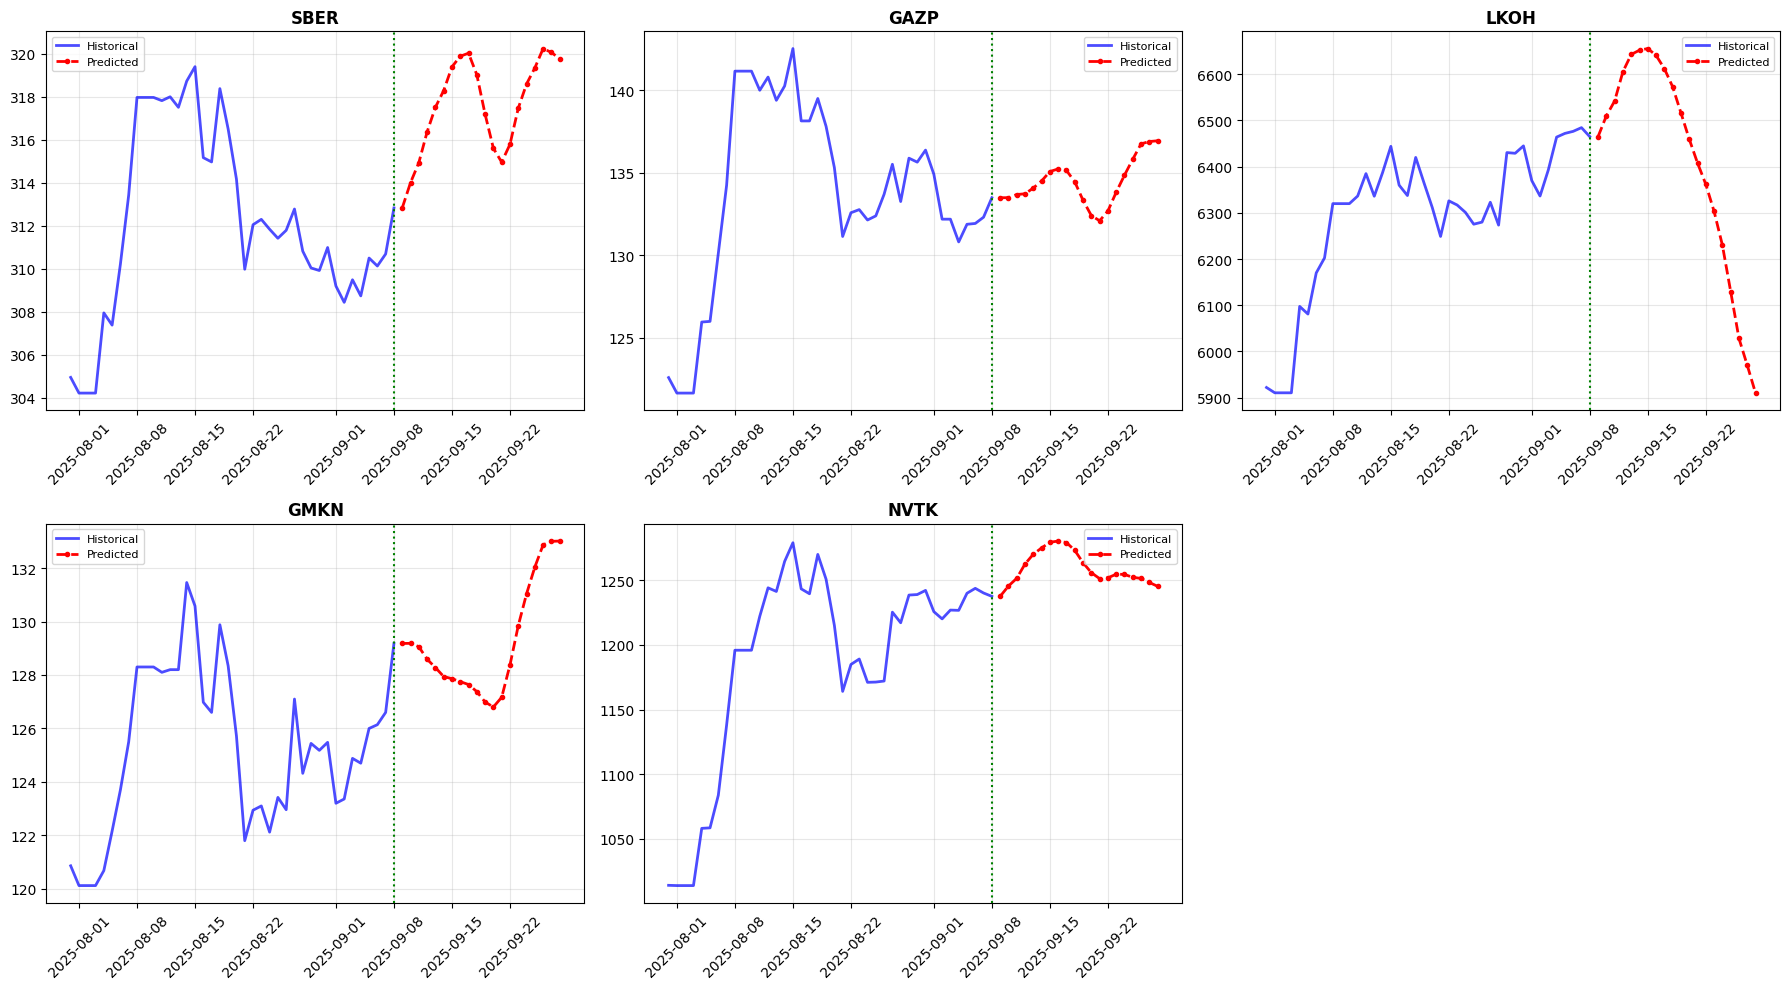

In [8]:
def generate_forecast(
    model, df_ticker, llm_ticker, feature_scaler, date_t,
    clip_pct=0.03, smooth_alpha=0.3, llm_weight=0.2
):
    model.eval()

    df_cut = df_ticker[df_ticker['begin'] <= date_t].copy()
    if len(df_cut) < INPUT_WINDOW:
        return {'R': np.zeros(PRED_HORIZON), 'P': np.zeros(PRED_HORIZON), 'prices': np.zeros(PRED_HORIZON)}

    ds = ImprovedTimeSeriesDataset(
        df_cut,
        llm_ticker,
        seq_len=INPUT_WINDOW,
        pred_horizon=PRED_HORIZON,
        feature_scaler=feature_scaler,
        is_train=False
    )

    if len(ds) == 0:
        return {'R': np.zeros(PRED_HORIZON), 'P': np.zeros(PRED_HORIZON), 'prices': np.zeros(PRED_HORIZON)}

    X, _, _ = ds[-1]
    X = X.unsqueeze(0).to(device)

    if hasattr(ds, "llm_feature_indices"):
        X[:, :, ds.llm_feature_indices] *= llm_weight

    with torch.no_grad():
        pred_log_returns, pred_probs = model(X)

    pred_log_returns = pred_log_returns.cpu().numpy().flatten()

    pred_log_returns = np.clip(pred_log_returns, -clip_pct, clip_pct)

    pred_log_returns = pd.Series(pred_log_returns).ewm(alpha=smooth_alpha).mean().values

    last_price = df_cut['close'].iloc[-1]
    cum_prices = last_price * np.exp(np.cumsum(pred_log_returns))

    smoothed_prices = pd.Series(cum_prices).rolling(window=5, min_periods=1, center=True).mean().values
    smoothed_prices = smoothed_prices / smoothed_prices[0] * last_price

    pred_log_returns = np.log(smoothed_prices[1:] / smoothed_prices[:-1])
    pred_log_returns = np.insert(pred_log_returns, 0, 0)

    return {
        'R': pred_log_returns,
        'P': pred_probs.cpu().numpy().flatten(),
        'prices': smoothed_prices
    }


import matplotlib.pyplot as plt

print("\n  Визуализация предсказаний для топ-5 тикеров...\n")

top_tickers = ['SBER', 'GAZP', 'LKOH', 'GMKN', 'NVTK']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, ticker in enumerate(top_tickers):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    df_t = CANDLES[CANDLES['ticker'] == ticker].copy()
    llm_ticker = LLM_FEATURES_DF[LLM_FEATURES_DF['ticker'] == ticker].copy()
    
    if len(df_t) < INPUT_WINDOW:
        ax.set_title(f"{ticker} - Not enough data")
        continue

    try:
        forecast = generate_forecast(
            trained_model, df_t, llm_ticker, feature_scaler, TRAIN_CUTOFF
        )
        daily_r = forecast['R']
        pred_prices = [df_t['close'].iloc[-1]]
        for r in daily_r:
            pred_prices.append(pred_prices[-1] * (1 + r))
        pred_prices = np.array(pred_prices[1:])
    except Exception as e:
        ax.set_title(f"{ticker} - Prediction Error: {e}")
        continue

    df_plot = df_t.groupby("begin").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    }).reset_index()
    df_plot = df_plot.set_index("begin").asfreq("D").ffill()
    
    last_date = df_plot.index[-1]
    pred_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=PRED_HORIZON)
    
    ax.plot(df_plot.index[-40:], df_plot["close"][-40:], 
              label="Historical", linewidth=2, color='blue', alpha=0.7)
    ax.plot(pred_dates, pred_prices, 
              label="Predicted", linestyle="--", linewidth=2, marker='o', markersize=3, color='red')
    ax.axvline(x=last_date, color='green', linestyle=':', linewidth=1.5)
    ax.set_title(f"{ticker}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax.tick_params(axis='x', rotation=45)

    
if len(axes) > len(top_tickers):
    for extra_ax in axes[len(top_tickers):]:
        extra_ax.axis('off')

plt.tight_layout()
plt.show()